In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import learning_curve

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import time

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000.000000,2.542400e+04,30000.000000,29828.000000,27507.000000,28297.000000,30000.000000,30000.000000,2.515000e+04,30000.000000,30000.000000,3.000000e+04,29660.000000
mean,40.092300,2.630574e+03,88826.333855,400.936876,2.253027,739.885381,0.193933,501.934700,2.631119e+03,2.460067,-4.743867,1.317597e+05,47649.342208
std,16.045129,1.126272e+04,59536.949605,242.545375,0.951162,72.163846,0.395384,288.158086,1.132268e+04,1.118562,74.614593,9.354955e+04,48221.146686
min,18.000000,3.777000e+02,6048.240000,-999.000000,1.000000,580.000000,0.000000,1.000000,3.777000e+02,1.000000,-999.000000,-9.990000e+02,-999.000000
25%,25.000000,1.650457e+03,41177.755000,247.667500,2.000000,681.880000,0.000000,251.000000,1.650450e+03,1.000000,1.000000,6.057216e+04,0.000000
50%,40.000000,2.222435e+03,75128.075000,375.205000,2.000000,739.820000,0.000000,504.000000,2.223250e+03,2.000000,1.000000,1.099936e+05,35209.395000
75%,55.000000,3.090593e+03,119964.605000,521.292500,3.000000,799.120000,0.000000,751.000000,3.091408e+03,3.000000,1.000000,1.788807e+05,74261.250000
max,65.000000,1.777460e+06,621497.820000,3840.880000,14.000000,896.260000,1.000000,999.000000,1.777460e+06,4.000000,1.000000,1.077967e+06,481907.320000


In [6]:
df.shape

(30000, 24)

In [7]:
df.isnull().sum()

Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64

In [8]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print(num_cols)
print(cat_cols)

Index(['Age', 'Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Property ID', 'Property Age', 'Property Type',
       'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)'],
      dtype='object')
Index(['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession',
       'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2',
       'Has Active Credit Card', 'Property Location'],
      dtype='object')


In [9]:
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [12]:
target = "Loan Sanction Amount (USD)"

X = df.drop(target,axis=1)
y = df[target]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

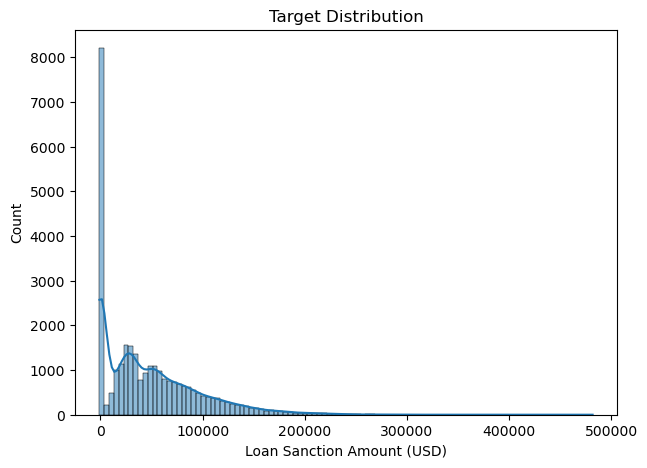

In [15]:
plt.figure(figsize=(7,5))
sns.histplot(y,kde=True)
plt.title("Target Distribution")
plt.show()

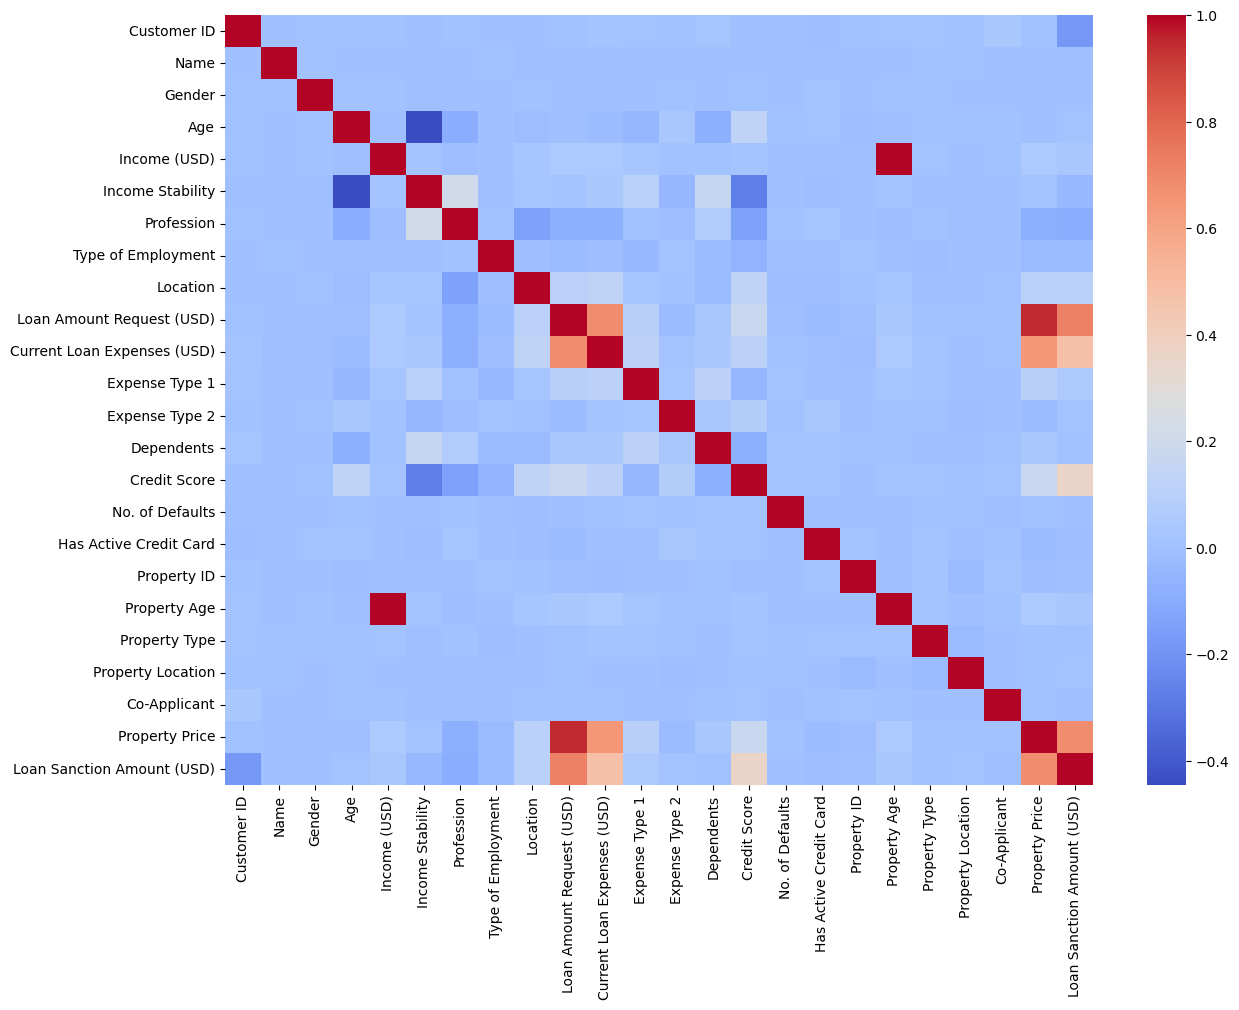

In [16]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

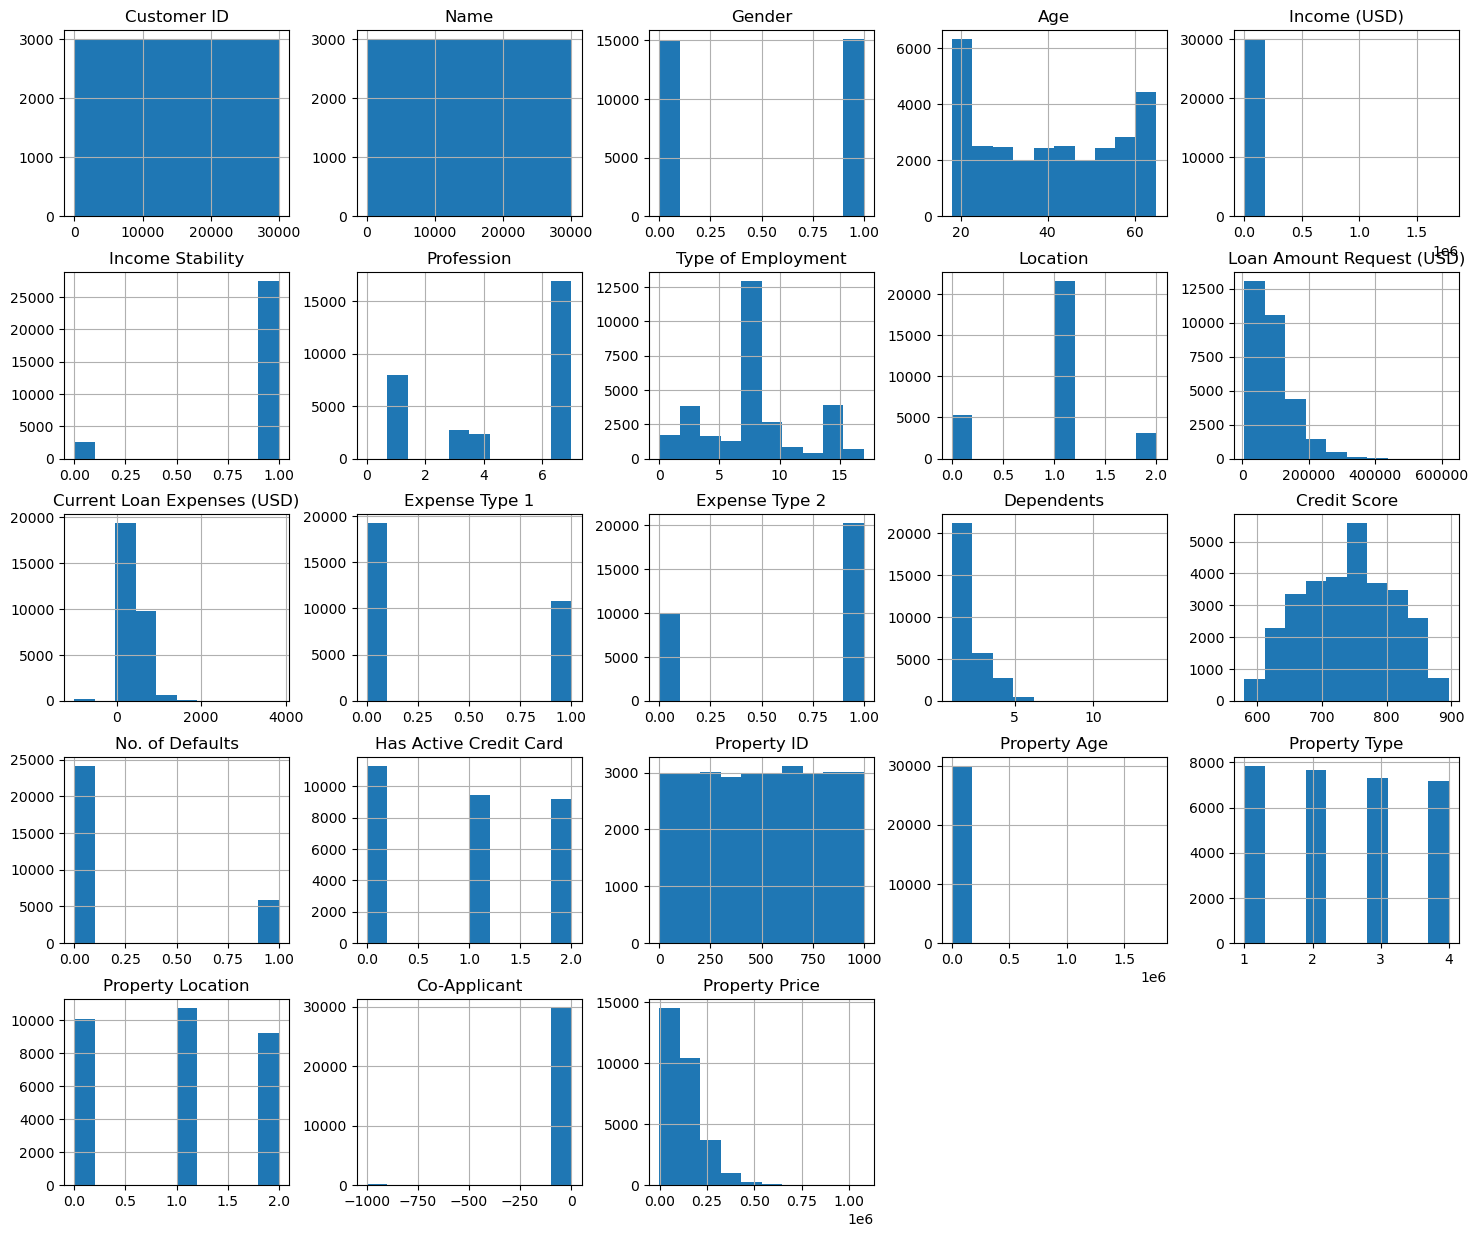

In [17]:
X.hist(figsize=(18,15))
plt.show()

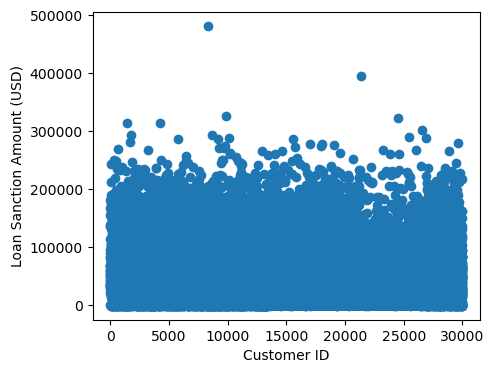

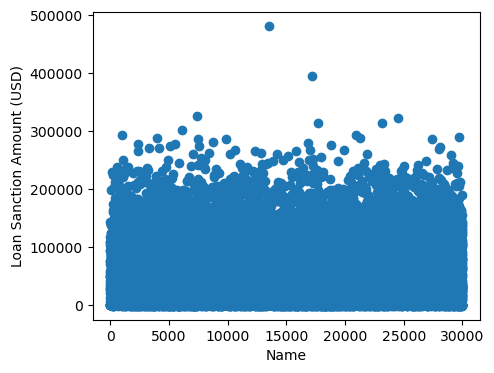

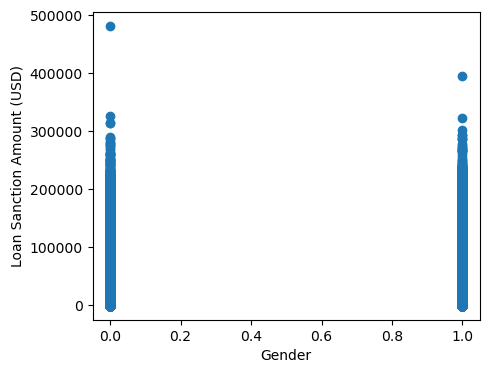

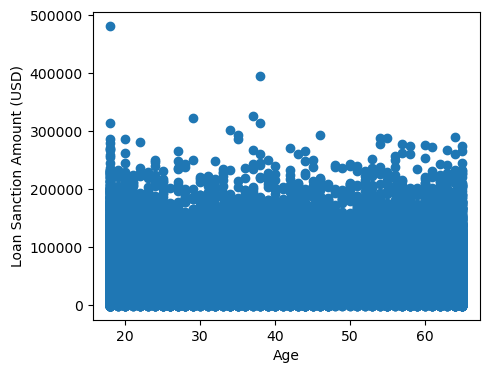

In [18]:
features = X.columns[:4]

for col in features:
    plt.figure(figsize=(5,4))
    plt.scatter(df[col],y)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

In [19]:
start=time.time()

linear=LinearRegression()
linear.fit(X_train,y_train)

linear_time=time.time()-start

linear_pred=linear.predict(X_test)

In [20]:
ridge=Ridge()

ridge_params={
    "alpha":[0.01,0.1,1,10,100]
}

ridge_grid=GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="r2"
)

start=time.time()

ridge_grid.fit(X_train,y_train)

ridge_time=time.time()-start

best_ridge=ridge_grid.best_estimator_

ridge_pred=best_ridge.predict(X_test)

In [21]:
lasso=Lasso(max_iter=10000)

lasso_params={
    "alpha":[0.001,0.01,0.1,1,10]
}

lasso_grid=GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="r2"
)

start=time.time()

lasso_grid.fit(X_train,y_train)

lasso_time=time.time()-start

best_lasso=lasso_grid.best_estimator_

lasso_pred=best_lasso.predict(X_test)

In [22]:
elastic=ElasticNet(max_iter=10000)

elastic_params={
    "alpha":[0.01,0.1,1,10],
    "l1_ratio":[0.2,0.5,0.8]
}

elastic_grid=GridSearchCV(
    elastic,
    elastic_params,
    cv=5,
    scoring="r2"
)

start=time.time()

elastic_grid.fit(X_train,y_train)

elastic_time=time.time()-start

best_elastic=elastic_grid.best_estimator_

elastic_pred=best_elastic.predict(X_test)

In [23]:
print("Ridge:",ridge_grid.best_params_)
print("Lasso:",lasso_grid.best_params_)
print("Elastic:",elastic_grid.best_params_)

Ridge: {'alpha': 0.01}
Lasso: {'alpha': 0.001}
Elastic: {'alpha': 0.01, 'l1_ratio': 0.8}


In [24]:
def evaluate(name,y_true,y_pred,time_taken):

    mae=mean_absolute_error(y_true,y_pred)

    mse=mean_squared_error(y_true,y_pred)

    rmse=np.sqrt(mse)

    r2=r2_score(y_true,y_pred)

    return [name,mae,mse,rmse,r2,time_taken]

In [25]:
results=[]

results.append(evaluate("Linear",y_test,linear_pred,linear_time))
results.append(evaluate("Ridge",y_test,ridge_pred,ridge_time))
results.append(evaluate("Lasso",y_test,lasso_pred,lasso_time))
results.append(evaluate("ElasticNet",y_test,elastic_pred,elastic_time))

results_df=pd.DataFrame(results,
columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "R2",
    "Training Time"
])

results_df

,Model,MAE,MSE,RMSE,R2,Training Time
0,Linear,20785.515776,9.615861e+08,31009.451645,0.582021,0.140568
1,Ridge,20785.493110,9.615719e+08,31009.222552,0.582027,0.328964
2,Lasso,20785.513851,9.615851e+08,31009.435624,0.582021,12.471020
3,ElasticNet,20790.806751,9.500145e+08,30822.305511,0.587051,2.503527


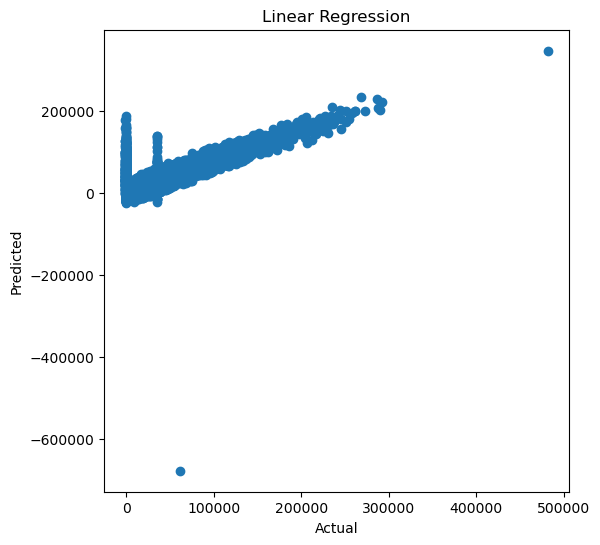

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,linear_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

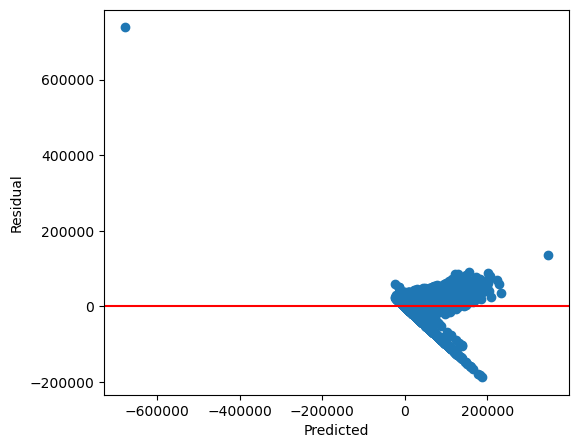

In [27]:
residual=y_test-linear_pred

plt.figure(figsize=(6,5))
plt.scatter(linear_pred,residual)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

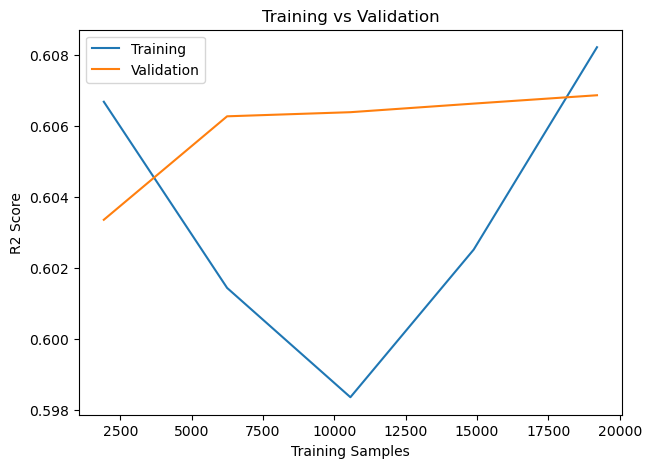

In [28]:
sizes,train_scores,test_scores=learning_curve(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

train_mean=train_scores.mean(axis=1)
test_mean=test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(sizes,train_mean,label="Training")
plt.plot(sizes,test_mean,label="Validation")
plt.legend()
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.title("Training vs Validation")
plt.show()

In [29]:
coef_df=pd.DataFrame({
    "Feature":X.columns,
    "Linear":linear.coef_,
    "Ridge":best_ridge.coef_,
    "Lasso":best_lasso.coef_,
    "Elastic":best_elastic.coef_
})

coef_df.head()

,Feature,Linear,Ridge,Lasso,Elastic
0,Customer ID,-8800.812554,-8800.829736,-8800.813325,-8790.940394
1,Name,-12.309539,-12.321938,-12.309519,-16.943040
2,Gender,-154.362513,-154.360217,-154.361277,-152.350135
3,Age,-557.867380,-557.842256,-557.864579,-550.269660
4,Income (USD),27773.939985,27654.039652,27764.314451,-482.364336


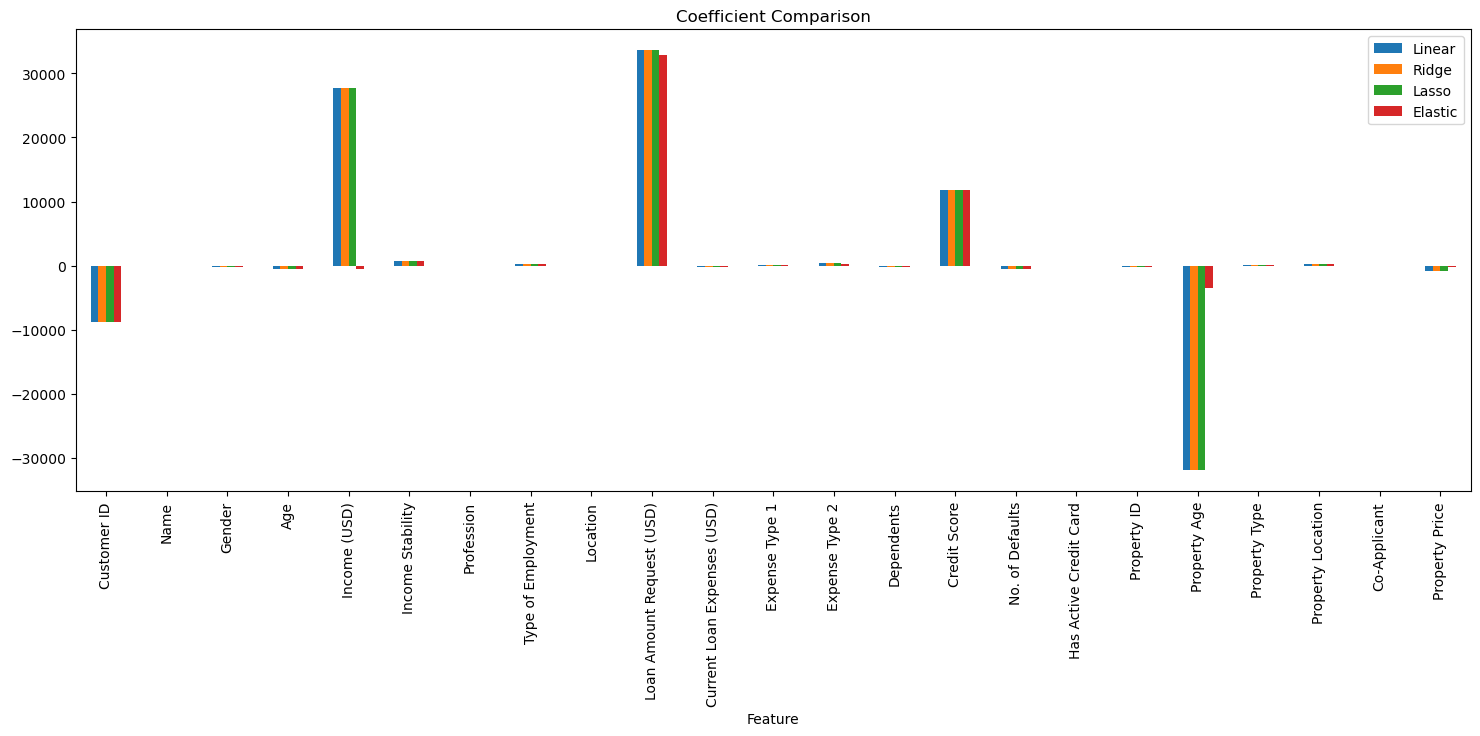

In [30]:
coef_df.set_index("Feature").plot(
    kind="bar",
    figsize=(18,6)
)

plt.title("Coefficient Comparison")
plt.show()

In [31]:
models = {
    "Linear": LinearRegression(),
    "Ridge": best_ridge,
    "Lasso": best_lasso,
    "ElasticNet": best_elastic
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_scaled,
        y,
        cv=5,
        scoring=("neg_mean_absolute_error",
                 "neg_mean_squared_error",
                 "r2")
    )

    mae = -scores["test_neg_mean_absolute_error"].mean()
    mse = -scores["test_neg_mean_squared_error"].mean()
    rmse = np.sqrt(mse)
    r2 = scores["test_r2"].mean()

    cv_results.append([name, mae, mse, rmse, r2])

cv_df = pd.DataFrame(
    cv_results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

cv_df

,Model,MAE,MSE,RMSE,R2
0,Linear,20893.637660,9.103090e+08,30171.326653,0.604015
1,Ridge,20893.625269,9.103060e+08,30171.277070,0.604016
2,Lasso,20893.277713,9.103003e+08,30171.182792,0.604018
3,ElasticNet,20900.936740,9.085391e+08,30141.982800,0.604775
